In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [14]:
df = pd.read_csv('../data/Algerian_forest_fires_dataset_cleaned.csv')
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [15]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [16]:
df.drop(['day', 'month', 'year'], axis=1, inplace=True)

In [17]:
df.columns

Index(['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI',
       'FWI', 'Classes', 'Region'],
      dtype='object')

In [18]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [19]:
df['Classes'] = np.where(df['Classes'].str.contains('not fire'), 0, 1)

In [20]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [21]:
X = df.drop('FWI', axis=1)
Y = df['FWI']

In [22]:
X.head(), Y.head()

(   Temperature  RH  Ws  Rain  FFMC  DMC    DC  ISI  BUI  Classes  Region
 0           29  57  18   0.0  65.7  3.4   7.6  1.3  3.4        0       0
 1           29  61  13   1.3  64.4  4.1   7.6  1.0  3.9        0       0
 2           26  82  22  13.1  47.1  2.5   7.1  0.3  2.7        0       0
 3           25  89  13   2.5  28.6  1.3   6.9  0.0  1.7        0       0
 4           27  77  16   0.0  64.8  3.0  14.2  1.2  3.9        0       0,
 0    0.5
 1    0.4
 2    0.1
 3    0.0
 4    0.5
 Name: FWI, dtype: float64)

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=24)

In [24]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((194, 11), (49, 11), (194,), (49,))

In [25]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.650746,-0.271323,-0.336926,0.685450,0.473555,0.362789,0.597212,0.446845,0.511963,0.289773
RH,-0.650746,1.000000,0.256252,0.247397,-0.660735,-0.404397,-0.210269,-0.687314,-0.345070,-0.434549,-0.430618
Ws,-0.271323,0.256252,1.000000,0.176705,-0.167299,0.034555,0.106605,0.028086,0.064996,-0.062897,-0.182938
Rain,-0.336926,0.247397,0.176705,1.000000,-0.556467,-0.292656,-0.303332,-0.357495,-0.304112,-0.389815,-0.035680
FFMC,0.685450,-0.660735,-0.167299,-0.556467,1.000000,0.596277,0.505526,0.739587,0.586284,0.776862,0.198558
DMC,0.473555,-0.404397,0.034555,-0.292656,0.596277,1.000000,0.879932,0.682868,0.982903,0.583161,0.201714
DC,0.362789,-0.210269,0.106605,-0.303332,0.505526,0.879932,1.000000,0.505829,0.942924,0.512612,-0.061808
ISI,0.597212,-0.687314,0.028086,-0.357495,0.739587,0.682868,0.505829,1.000000,0.645218,0.740409,0.276821
BUI,0.446845,-0.345070,0.064996,-0.304112,0.586284,0.982903,0.942924,0.645218,1.000000,0.586893,0.101664
Classes,0.511963,-0.434549,-0.062897,-0.389815,0.776862,0.583161,0.512612,0.740409,0.586893,1.000000,0.150101


<Axes: >

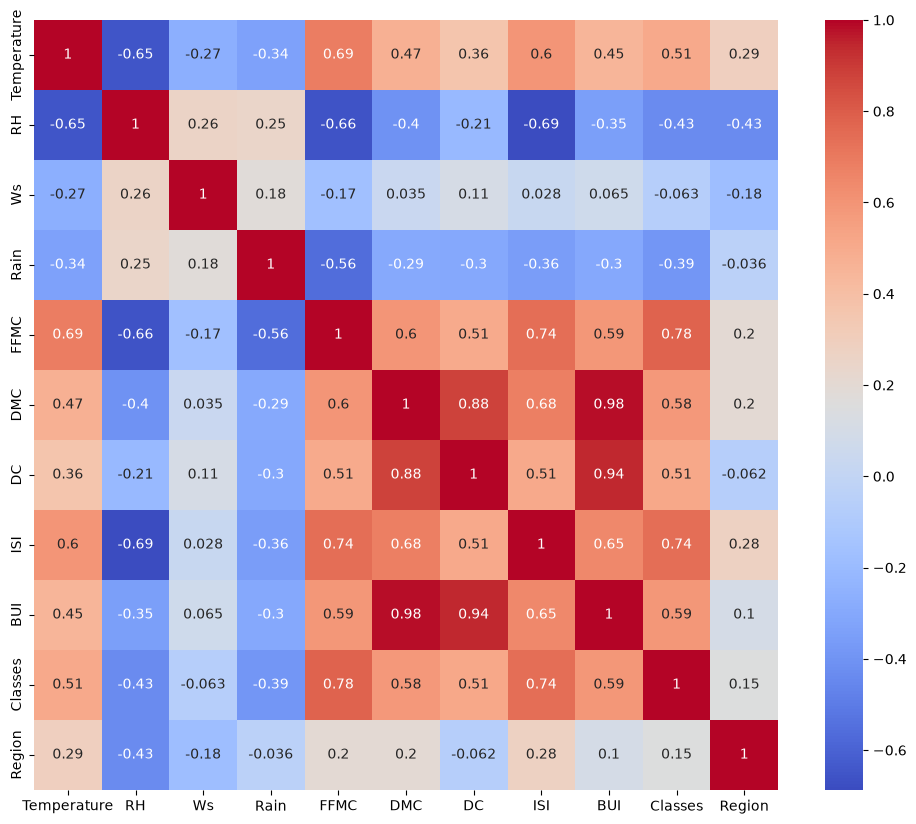

In [26]:
plt.figure(figsize=(12, 10))
sns.heatmap(X_train.corr(), annot=True, cmap='coolwarm')

In [27]:
def correlation(dataset, threshold):
    corr_col = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if corr_matrix.iloc[i,j] > threshold:
                column = corr_matrix.columns[i]
                corr_col.add(column)
    return corr_col

In [28]:
corr_features = correlation(X_train, 0.80)

In [29]:
X_train.drop(corr_features, axis=1, inplace=True)

In [30]:
X_test.drop(corr_features, axis=1, inplace=True)

In [31]:
X_train.shape, X_test.shape

((194, 9), (49, 9))

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
X_train_scaled

array([[-0.8050142 ,  1.2240393 , -0.5194664 , ..., -1.04820719,
        -1.12063105,  1.04212356],
       [-0.53621428,  0.74068793, -0.5194664 , ..., -0.61681774,
        -1.12063105,  1.04212356],
       [ 0.53898541, -1.39986815, -0.17196129, ..., -0.59285166,
        -1.12063105,  1.04212356],
       ...,
       [ 2.15178494, -2.1594203 , -0.17196129, ...,  2.85826397,
         0.89235436,  1.04212356],
       [-0.53621428, -1.46891834, -0.17196129, ...,  0.89304535,
         0.89235436,  1.04212356],
       [ 0.53898541, -0.4331654 , -0.17196129, ..., -0.73664814,
        -1.12063105,  1.04212356]], shape=(194, 9))

{'whiskers': [<matplotlib.lines.Line2D at 0x1b7f9be1a90>,
 'caps': [<matplotlib.lines.Line2D at 0x1b7f9be1d10>,
 'boxes': [<matplotlib.lines.Line2D at 0x1b7f9be1950>,
 'medians': [<matplotlib.lines.Line2D at 0x1b7f9be1f90>,
 'fliers': [<matplotlib.lines.Line2D at 0x1b7f9be20d0>,
 'means': []}

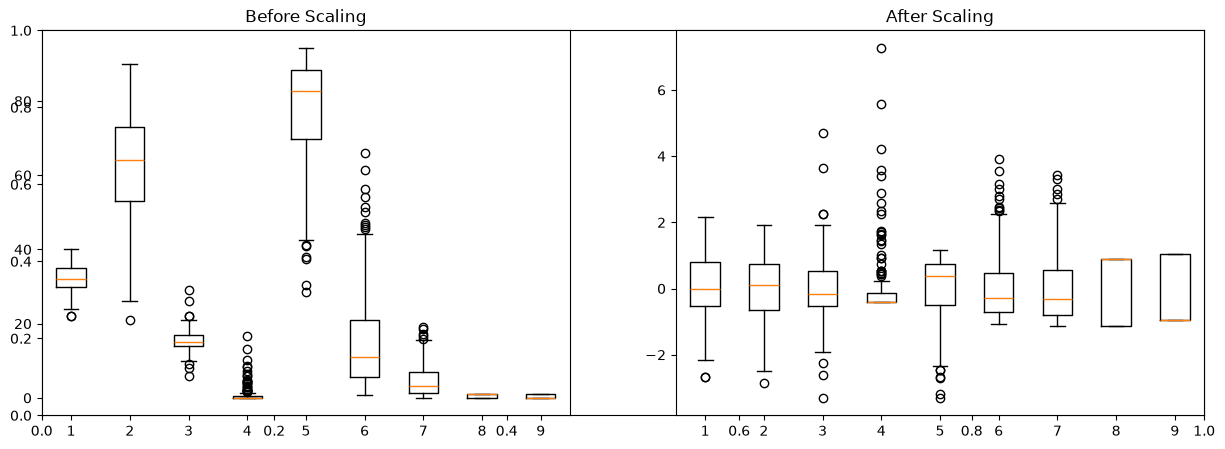

In [34]:
plt.subplots(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.title('Before Scaling')
plt.boxplot(X_train)
plt.subplot(1, 2, 2)
plt.title('After Scaling')
plt.boxplot(X_train_scaled)

Mean Squared Error: 0.6833274680027921
R2 Score: 0.9847830197069042


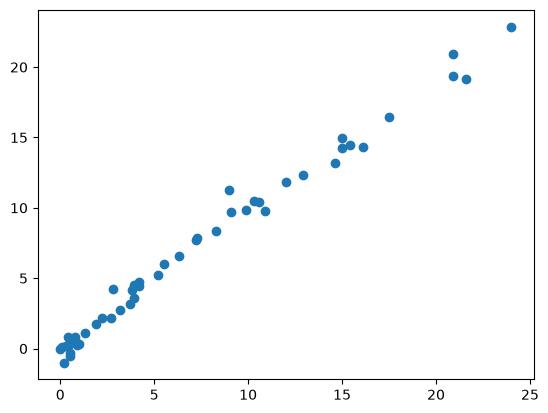

In [35]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

regression = LinearRegression()

regression.fit(X_train_scaled, Y_train)
y_pred = regression.predict(X_test_scaled)
mae = mean_squared_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)
print(f'Mean Squared Error: {mae}')
print(f'R2 Score: {r2}')
plt.scatter(Y_test, y_pred)
# plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'k--', lw=4)

In [36]:
lasso = Lasso()
lasso.fit(X_train_scaled, Y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
mae_lasso = mean_squared_error(Y_test, y_pred_lasso)
r2_lasso = r2_score(Y_test, y_pred_lasso)
print(f'Mean Squared Error (Lasso): {mae_lasso}')
print(f'R2 Score (Lasso): {r2_lasso}')

Mean Squared Error (Lasso): 2.4571465825504974
R2 Score (Lasso): 0.9452819433218422


In [37]:
ridge = Ridge()
ridge.fit(X_train_scaled, Y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
mae_ridge = mean_squared_error(Y_test, y_pred_ridge)
r2_ridge = r2_score(Y_test, y_pred_ridge)
print(f'Mean Squared Error (Ridge): {mae_ridge}')
print(f'R2 Score (Ridge): {r2_ridge}')

Mean Squared Error (Ridge): 0.7119686069158887
R2 Score (Ridge): 0.9841452118229532


In [38]:
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet()
elastic_net.fit(X_train_scaled, Y_train)
elastic_net_pred = elastic_net.predict(X_test_scaled)
elastic_net_mae = mean_squared_error(Y_test, elastic_net_pred)
elastic_net_r2 = r2_score(Y_test, elastic_net_pred)
print(f'Mean Squared Error (Elastic Net): {elastic_net_mae}')
print(f'R2 Score (Elastic Net): {elastic_net_r2}')

Mean Squared Error (Elastic Net): 5.065234683666773
R2 Score (Elastic Net): 0.8872025786018191


In [39]:
from sklearn.linear_model import LassoCV
lasso_cv = LassoCV(cv=5)

In [40]:
import pickle
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(ridge, open('ridge_model.pkl', 'wb'))